# EDA: Elliptic Bitcoin Dataset

Цели:
- загрузить граф через `src.datasets.load_elliptic`;
- распределение классов (licit / illicit / unknown);
- таблица баланса по train/test сплитам;
- positive_class = illicit определяется программно (миноритарный размеченный).

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('..'))

import torch
import pandas as pd
import matplotlib.pyplot as plt

from src.datasets import load_elliptic

data, meta = load_elliptic(root='../data/elliptic')
print(data)
meta

Data(x=[203769, 165], edge_index=[2, 234355], y=[203769], train_mask=[203769], test_mask=[203769])


{'num_nodes': 203769,
 'num_edges': 234355,
 'num_features': 165,
 'label_counts': {0: 42019, 1: 4545, 2: 157205},
 'positive_class': 1,
 'n_labeled': 46564,
 'splits': {'train': {'n': 29894,
   'n_pos': 3462,
   'n_neg': 26432,
   'pos_rate': 0.11580919248009634},
  'test': {'n': 16670,
   'n_pos': 1083,
   'n_neg': 15587,
   'pos_rate': 0.06496700659868027}}}

## Распределение классов
y: 0 = licit, 1 = illicit (positive, миноритарный), 2 = unknown.

positive_class = 1 (illicit)


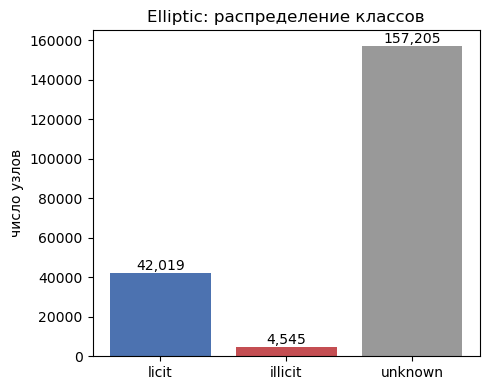

In [2]:
label_names = {0: 'licit', 1: 'illicit', 2: 'unknown'}
counts = meta['label_counts']
labels = [label_names.get(k, str(k)) for k in counts]
values = list(counts.values())

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(labels, values, color=['#4c72b0', '#c44e52', '#999999'])
ax.set_ylabel('число узлов')
ax.set_title('Elliptic: распределение классов')
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width()/2, v, f'{v:,}', ha='center', va='bottom')
plt.tight_layout()
print('positive_class =', meta['positive_class'], '(illicit)')
plt.show()

## Баланс классов по train/test (встроенный временно́й сплит)

In [3]:
rows = []
for split, s in meta['splits'].items():
    rows.append({
        'split': split,
        'n_labeled': s['n'],
        'n_illicit (pos)': s['n_pos'],
        'n_licit (neg)': s['n_neg'],
        'pos_rate': round(s['pos_rate'], 4),
    })
df = pd.DataFrame(rows).set_index('split')
df

,n_labeled,n_illicit (pos),n_licit (neg),pos_rate
split,,,,
train,29894,3462,26432,0.1158
test,16670,1083,15587,0.0650


In [4]:
# Сверка кодировки меток на рантайме (не хардкодим).
vals, cnts = torch.unique(data.y, return_counts=True)
for v, c in zip(vals.tolist(), cnts.tolist()):
    print(f'label {v} ({label_names.get(v, "?")}): {c:,}')

label 0 (licit): 42,019
label 1 (illicit): 4,545
label 2 (unknown): 157,205
